Bank Customer Risk Segmentation Using Expectation-Maximization
Complete Python Script



1. IMPORT LIBRARIES



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import warnings
warnings.filterwarnings("ignore")

# Set seed for reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")




2. LOAD DATA

In [2]:
print("Loading observable feature dataset...")
df_em = pd.read_csv("bank_customer_em.csv")

print("\n--- Dataset Shape ---")
print(df_em.shape)

print("\n--- First 5 Rows ---")
print(df_em.head())

print("\n--- Missing Values ---")
print(df_em.isnull().sum())



Loading observable feature dataset...

--- Dataset Shape ---
(2000, 14)

--- First 5 Rows ---
  customer_id  age  annual_income  monthly_expense  savings_balance  \
0    CUST0001   44         745700            54350            84300   
1    CUST0002   31        1120800            38350          1397800   
2    CUST0003   27        1275500            40550          1173900   
3    CUST0004   53        2853300           103850          1842800   
4    CUST0005   47         331400            24550            39500   

   debt_to_income_ratio  credit_utilization  average_transaction_amount  \
0                  0.70                65.8                        3309   
1                  0.26                15.3                        2668   
2                  0.19                27.2                        6907   
3                  0.23                29.8                        3890   
4                  0.63                89.2                        1314   

   monthly_transaction_count


3. DATA PREPROCESSING

    Remove customer_id from feature matrix


In [3]:
df_features = df_em.drop(columns=['customer_id'])

# Handle missing values and duplicates
df_features = df_features.dropna()
df_features = df_features.drop_duplicates()

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_features.columns)

print("\nData successfully scaled.")




Data successfully scaled.



4. EXPLORATORY DATA ANALYSIS (EDA)




Generating EDA plots...


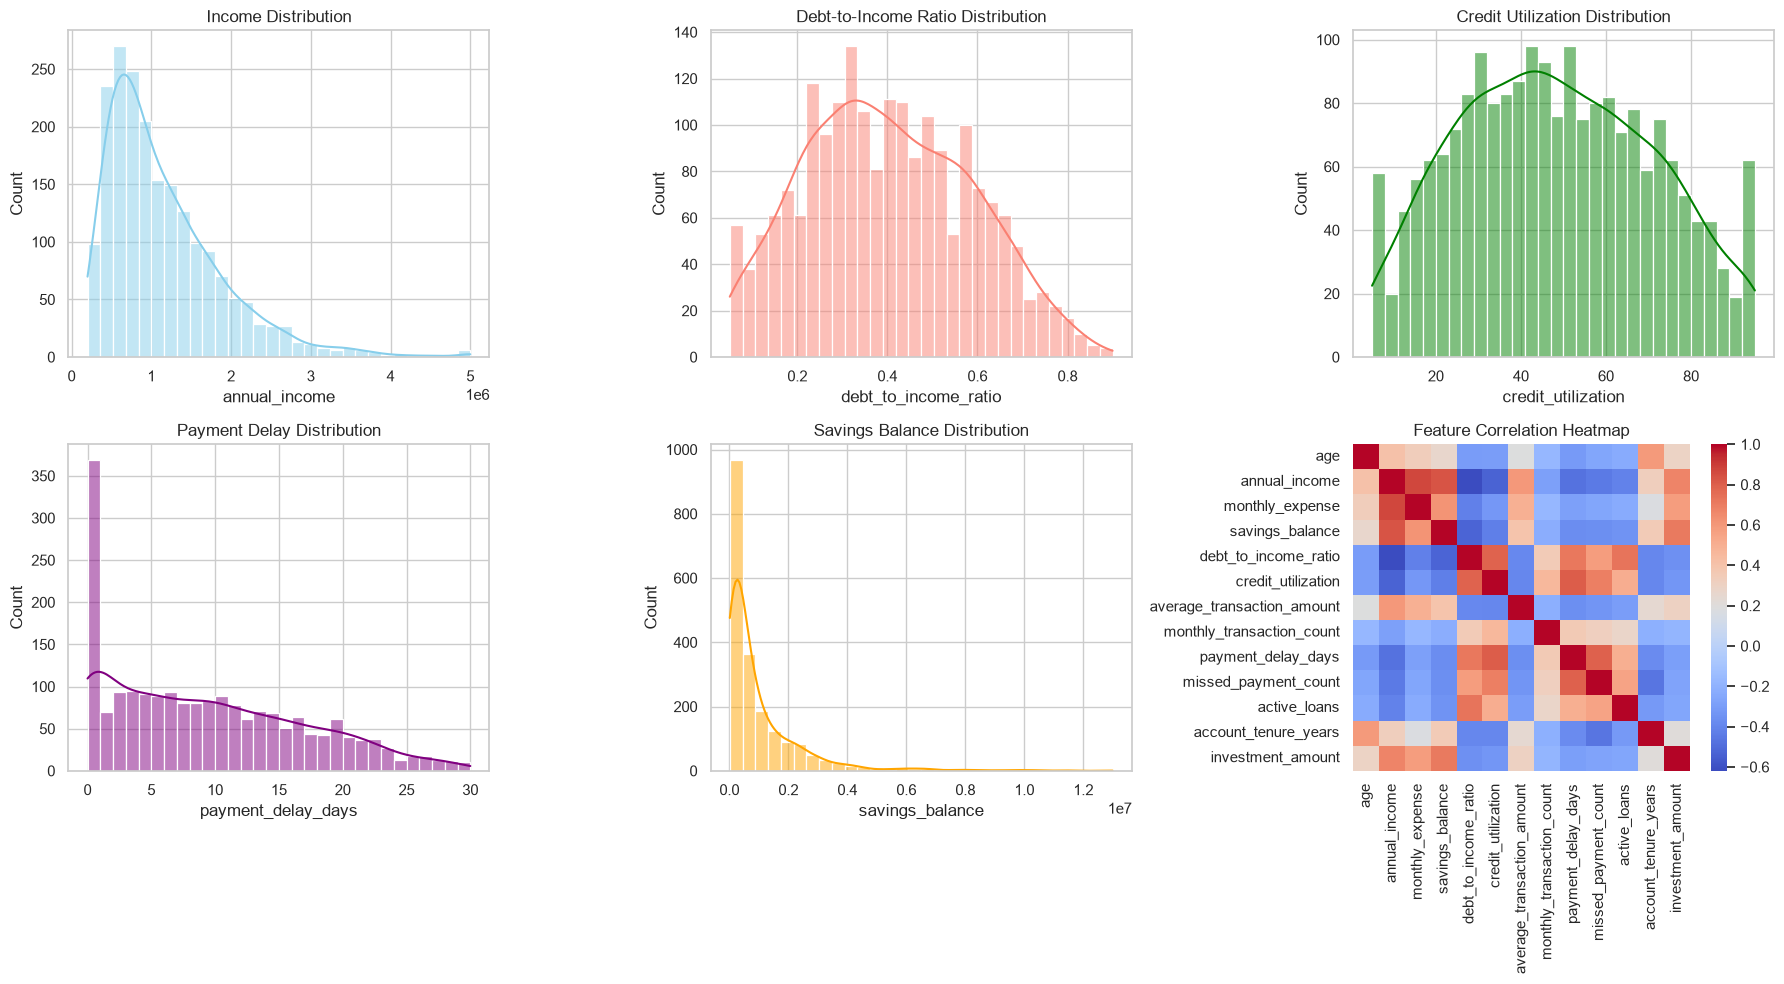

In [4]:
print("\nGenerating EDA plots...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df_features['annual_income'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Income Distribution')

sns.histplot(df_features['debt_to_income_ratio'], bins=30, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Debt-to-Income Ratio Distribution')

sns.histplot(df_features['credit_utilization'], bins=30, kde=True, ax=axes[0,2], color='green')
axes[0,2].set_title('Credit Utilization Distribution')

sns.histplot(df_features['payment_delay_days'], bins=30, kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Payment Delay Distribution')

sns.histplot(df_features['savings_balance'], bins=30, kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title('Savings Balance Distribution')

sns.heatmap(df_features.corr(), annot=False, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()




5. EM ALGORITHM / GMM IMPLEMENTATION


Training Expectation-Maximization (GMM) model...
Final model converged in 18 iterations.


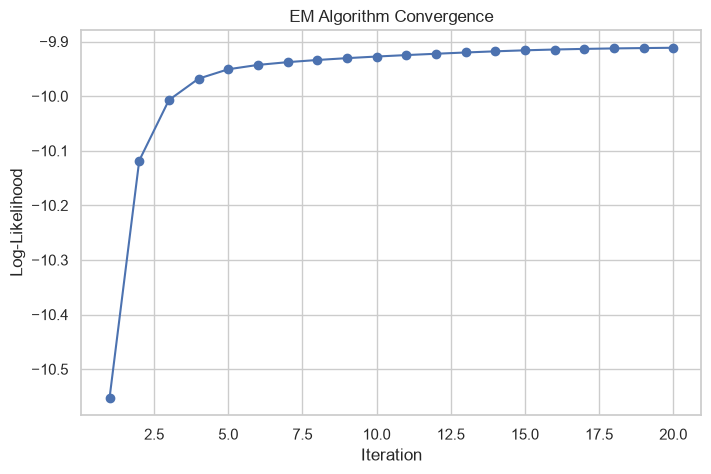

In [5]:
print("\nTraining Expectation-Maximization (GMM) model...")
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled_df)
print(f"Final model converged in {gmm.n_iter_} iterations.")

# Show Convergence Plot
gmm_track = GaussianMixture(n_components=3, max_iter=1, warm_start=True, random_state=42)
log_likelihoods = []

for i in range(20):
    gmm_track.fit(X_scaled_df)
    log_likelihoods.append(gmm_track.lower_bound_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 21), log_likelihoods, marker='o', linestyle='-')
plt.title("EM Algorithm Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()




6. E-STEP RESPONSIBILITIES & M-STEP ASSIGNMENTS

   E-Step: Calculate probabilities


In [6]:
responsibilities = gmm.predict_proba(X_scaled_df)

# Final cluster assignment
df_em['cluster'] = gmm.predict(X_scaled_df)

print("\nCluster Distribution:")
print(df_em['cluster'].value_counts())




Cluster Distribution:
cluster
0    846
1    834
2    320
Name: count, dtype: int64



7. INTERPRET THE CLUSTERS

In [7]:
interpretation_cols = [
    'annual_income', 'monthly_expense', 'savings_balance', 
    'debt_to_income_ratio', 'credit_utilization', 
    'payment_delay_days', 'missed_payment_count', 
    'cluster'
]

cluster_profile = df_em[interpretation_cols].groupby('cluster').mean()
print("\n--- Cluster Profiles (Means) ---")
print(cluster_profile.T)




--- Cluster Profiles (Means) ---
cluster                           0             1             2
annual_income         595440.425532  1.261727e+06  2.344093e+06
monthly_expense        32303.309693  5.168981e+04  8.277016e+04
savings_balance       178865.366430  9.333213e+05  3.317854e+06
debt_to_income_ratio       0.534196  3.326019e-01  2.248125e-01
credit_utilization        63.696099  3.902986e+01  3.095000e+01
payment_delay_days        14.219385  6.273022e+00  4.411250e+00
missed_payment_count       3.239953  1.473621e+00  1.006250e+00


Determine mapping based on the profiles
NOTE: Adjust this dictionary if the cluster means change!
Based on typical results: 
Highest debt/delay -> High_Risk
Lowest debt/delay -> Low_Risk
Middle -> Medium_Risk


In [8]:

mapping_dict = {
    0: 'Medium_Risk', # Update based on actual means output
    1: 'High_Risk',   # Update based on actual means output
    2: 'Low_Risk'     # Update based on actual means output
}

df_em['predicted_risk_group'] = df_em['cluster'].map(mapping_dict)




8. VISUALIZE DISCOVERED CLUSTERS (PCA)



Generating PCA Cluster Visualization...


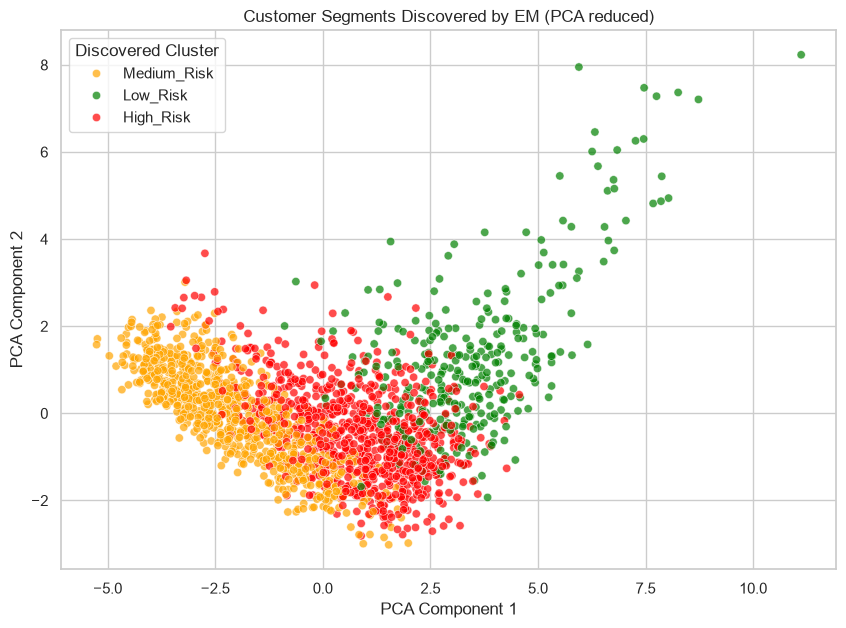

In [9]:
print("\nGenerating PCA Cluster Visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

df_em['pca_x'] = X_pca[:, 0]
df_em['pca_y'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca_x', y='pca_y', 
    hue='predicted_risk_group', 
    palette={'Low_Risk': 'green', 'Medium_Risk': 'orange', 'High_Risk': 'red'},
    data=df_em, 
    alpha=0.7
)
plt.title("Customer Segments Discovered by EM (PCA reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title='Discovered Cluster')
plt.show()




9. COMPARE WITH GROUND TRUTH


In [10]:
print("\nLoading ground truth for validation...")
df_truth = pd.read_csv("bank_customer_ground_truth.csv")

# Merge on customer_id
df_final = pd.merge(df_em, df_truth, on='customer_id')




Loading ground truth for validation...



10. METRICS & CONFUSION MATRIX


--- Classification Report ---
              precision    recall  f1-score   support

   High_Risk       0.05      0.08      0.06       500
    Low_Risk       0.92      0.37      0.52       800
 Medium_Risk       0.41      0.50      0.45       700

    accuracy                           0.34      2000
   macro avg       0.46      0.31      0.34      2000
weighted avg       0.52      0.34      0.38      2000

Overall Accuracy: 0.3390
Adjusted Rand Index (ARI): 0.2449
Normalized Mutual Information (NMI): 0.3157


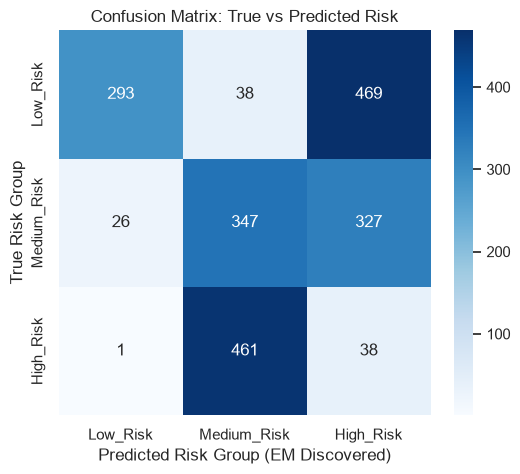

In [11]:
labels = ['Low_Risk', 'Medium_Risk', 'High_Risk']

print("\n--- Classification Report ---")
print(classification_report(df_final['true_risk_group'], df_final['predicted_risk_group']))

print(f"Overall Accuracy: {accuracy_score(df_final['true_risk_group'], df_final['predicted_risk_group']):.4f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(df_final['true_risk_group'], df_final['cluster']):.4f}")
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(df_final['true_risk_group'], df_final['cluster']):.4f}")

cm = confusion_matrix(df_final['true_risk_group'], df_final['predicted_risk_group'], labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix: True vs Predicted Risk")
plt.ylabel("True Risk Group")
plt.xlabel("Predicted Risk Group (EM Discovered)")
plt.show()




11. FINAL CUSTOMER RISK PROFILE

In [12]:
df_final['risk_probability'] = np.max(responsibilities, axis=1)

final_columns = [
    'customer_id', 'predicted_risk_group', 'risk_probability',
    'annual_income', 'debt_to_income_ratio', 'credit_utilization',
    'payment_delay_days', 'missed_payment_count'
]

final_profile_df = df_final[final_columns]

print("\n--- Final Customer Risk Profile (Sample) ---")
print(final_profile_df.sample(10, random_state=42))



--- Final Customer Risk Profile (Sample) ---
     customer_id predicted_risk_group  risk_probability  annual_income  \
1860    CUST1861            High_Risk          0.999979        1320200   
353     CUST0354            High_Risk          0.890132         760200   
1333    CUST1334            High_Risk          0.987784        1232200   
905     CUST0906             Low_Risk          0.995860        1671300   
1289    CUST1290             Low_Risk          0.671680        1723000   
1273    CUST1274            High_Risk          0.768255        1031700   
938     CUST0939            High_Risk          0.979313        1333900   
1731    CUST1732          Medium_Risk          0.999442         906000   
65      CUST0066          Medium_Risk          0.582402         744100   
1323    CUST1324            High_Risk          0.995034        1365600   

      debt_to_income_ratio  credit_utilization  payment_delay_days  \
1860                  0.40                73.4                10.5   